# Exploratory Data Analysis

In [366]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation, PillowWriter

from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
import seaborn as sns

df = pd.read_csv("pv_data.csv", sep=";")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)

Beginning: 2022-02-07 14:00:00
End: 2025-06-16 23:45:00
Span: 1225 days 09:45:00 

       Solarproduktion Tracker 1  Solarproduktion Tracker 2  Solarproduktion
count              113896.000000              113896.000000    113896.000000
mean                  113.128389                 214.986268       328.114657
std                   188.830633                 375.524054       506.766364
min                     0.000000                   0.000000         0.000000
25%                     0.000000                   0.000000         0.000000
50%                     1.000000                   0.000000         2.000000
75%                   149.000000                 245.000000       522.000000
max                  1125.000000                1721.000000      2361.000000
Most productive day: 2023-05-24 14:15:00
Least productive day: 2022-02-07 18:30:00


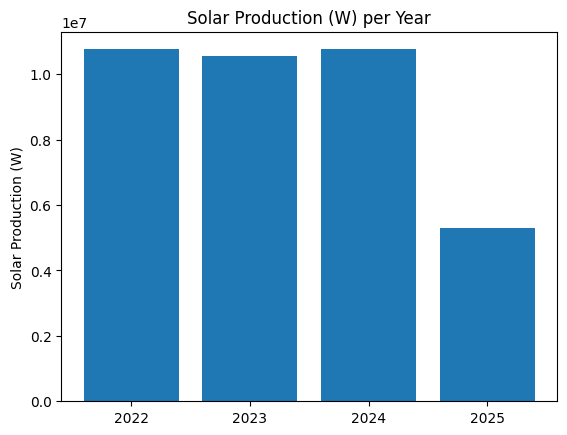

In [360]:
# Summary statistics
print("Beginning:",df.index.min())
print("End:",df.index.max())
print("Span:",df.index.max()-df.index.min(),"\n")
print(df[["Solarproduktion Tracker 1", "Solarproduktion Tracker 2", "Solarproduktion"]].describe())

print("Most productive day:", df["Solarproduktion"].idxmax())
print("Least productive day:", df["Solarproduktion"].idxmin())

df_yearly = df.resample("YE").sum()
plt.bar(['2022', '2023', '2024', '2025'], df_yearly['Solarproduktion'], color='C0')
plt.title("Solar Production (W) per Year")
plt.ylabel("Solar Production (W)")
plt.show()

# Ratio of North-East (1) and South-West (2) Trackers

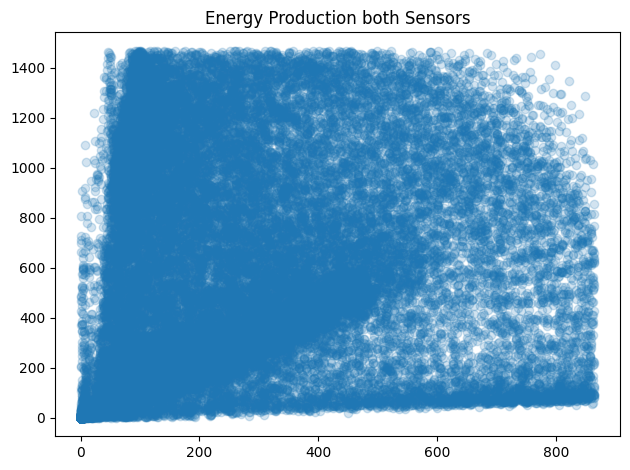

In [80]:
filter_hours = (7, 17)
df_filtered = df[(filter_hours[0] <= df.index.hour) & (df.index.hour <= filter_hours[1])]

q_low = 0.01
q_high = 0.99

df_filtered = df_filtered[
    (df_filtered["Solarproduktion Tracker 1"].between(
        df_filtered["Solarproduktion Tracker 1"].quantile(q_low),
        df_filtered["Solarproduktion Tracker 1"].quantile(q_high)
    )) &
    (df_filtered["Solarproduktion Tracker 2"].between(
        df_filtered["Solarproduktion Tracker 2"].quantile(q_low),
        df_filtered["Solarproduktion Tracker 2"].quantile(q_high)
    ))
]

plt.scatter(df_filtered["Solarproduktion Tracker 1"], df_filtered["Solarproduktion Tracker 2"], alpha=0.2)
plt.title("Energy Production both Sensors")
plt.tight_layout()
plt.show()

## Ratios in Different Resolutions

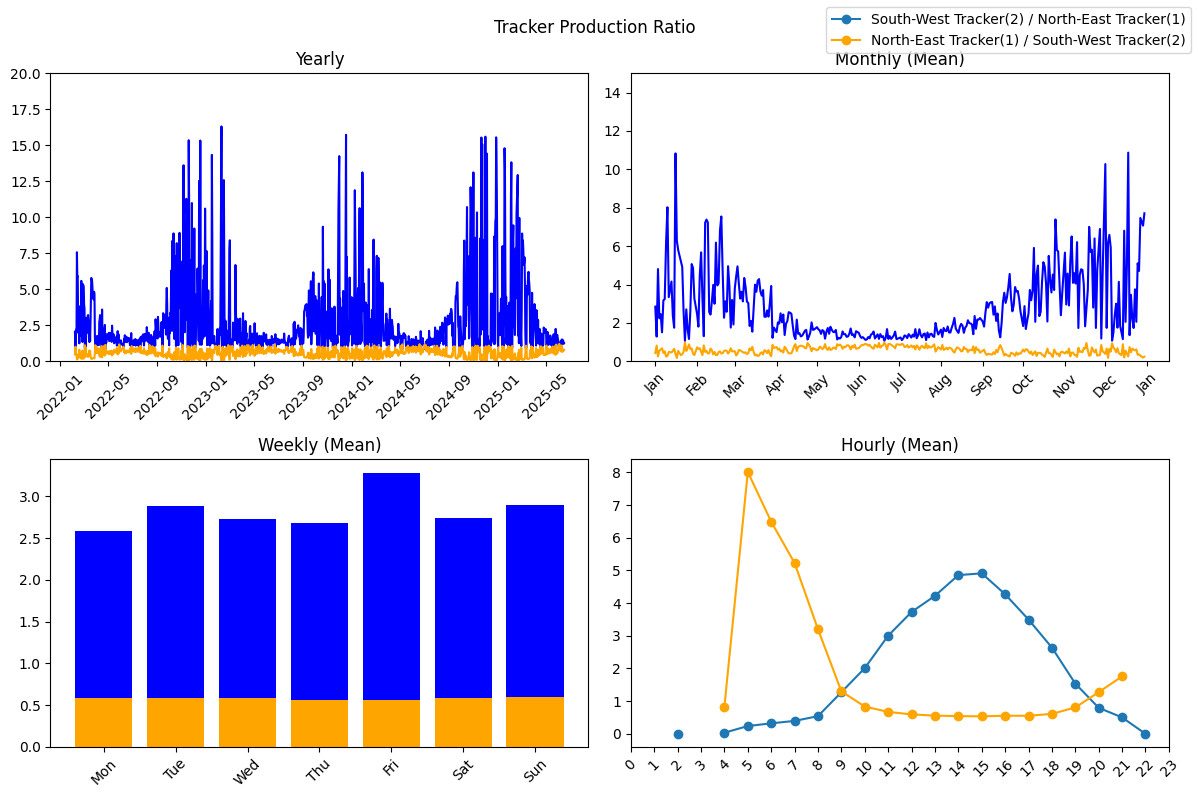

In [303]:
df_daily = df.resample('D').mean()
ratios_all = (df_daily["Solarproduktion Tracker 2"]/df_daily["Solarproduktion Tracker 1"]).replace([np.inf, -np.inf], np.nan).dropna()
ratios_all_nout = ratios_all[ratios_all.between(ratios_all.quantile(0.01), ratios_all.quantile(0.99))]

r_ratios_all = (df_daily["Solarproduktion Tracker 1"]/df_daily["Solarproduktion Tracker 2"]).replace([np.inf, -np.inf], np.nan).dropna()
r_ratios_all_nout = r_ratios_all[r_ratios_all.between(r_ratios_all.quantile(0.01), r_ratios_all.quantile(0.99))]

fig, ax = plt.subplots(2, 2, figsize = (12, 8))

#ax[0][0].plot(ratios_all.index, ratios_all, color='gray')
ax[0][0].plot(ratios_all_nout.index, ratios_all_nout, color='blue')
ax[0][0].plot(r_ratios_all_nout.index, r_ratios_all_nout, color='orange')
ax[0][0].set_ylim(0, 20)
ax[0][0].set_title("Yearly")
ax[0][0].tick_params(axis='x', labelrotation=45)

ratios_all_yl = ratios_all[~((ratios_all.index.month == 2) & (ratios_all.index.day == 29))]
ratios_all_yl = ratios_all_yl.groupby([ratios_all_yl.index.month, ratios_all_yl.index.day]).mean()
ratios_all_yl.index = pd.to_datetime([f"1970-{m:02d}-{d:02d}" for m, d in ratios_all_yl.index])
ratios_all_yl.sort_index(inplace=True)
ratios_all_nout = ratios_all_yl[ratios_all_yl.between(ratios_all_yl.quantile(0.01), ratios_all_yl.quantile(0.99))]

r_ratios_all_yl = r_ratios_all[~((r_ratios_all.index.month == 2) & (r_ratios_all.index.day == 29))]
r_ratios_all_yl = r_ratios_all_yl.groupby([r_ratios_all_yl.index.month, r_ratios_all_yl.index.day]).mean()
r_ratios_all_yl.index = pd.to_datetime([f"1970-{m:02d}-{d:02d}" for m, d in r_ratios_all_yl.index])
r_ratios_all_yl.sort_index(inplace=True)
r_ratios_all_nout = r_ratios_all_yl[r_ratios_all_yl.between(r_ratios_all_yl.quantile(0.01), r_ratios_all_yl.quantile(0.99))]
#ax[0][1].plot(ratios_all_yl.index, ratios_all_yl, color='gray')
ax[0][1].plot(ratios_all_nout.index, ratios_all_nout, color='blue')
ax[0][1].plot(r_ratios_all_nout.index, r_ratios_all_nout, color='orange')
ax[0][1].set_ylim(0, 15)
ax[0][1].set_title("Monthly (Mean)")
ax[0][1].tick_params(axis='x', labelrotation=45)
ax[0][1].xaxis.set_major_locator(mdates.MonthLocator())
ax[0][1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ratios_all_ml = ratios_all_nout.groupby([ratios_all_nout.index.weekday]).mean()
r_ratios_all_ml = r_ratios_all_nout.groupby([r_ratios_all_nout.index.weekday]).mean()
ax[1][0].bar(ratios_all_ml.index, ratios_all_ml, color='blue')
ax[1][0].bar(r_ratios_all_ml.index, r_ratios_all_ml, color='orange')
ax[1][0].set_title("Weekly (Mean)")
ax[1][0].set_xticks(range(7))
ax[1][0].set_xticklabels(calendar.day_abbr, rotation=45)

ratios_all_h = (df["Solarproduktion Tracker 2"]/df["Solarproduktion Tracker 1"]).replace([np.inf, -np.inf], np.nan).dropna().resample('h').mean()
ratios_all_day = ratios_all_h.groupby([ratios_all_h.index.hour]).mean()
ratios_all_day.index = pd.Index(ratios_all_day.index, name="hour")
ratios_all_day = ratios_all_day.sort_index()
ax[1][1].plot(ratios_all_day.index, ratios_all_day, marker='o', label="South-West Tracker(2) / North-East Tracker(1)")

r_ratios_all_h = (df["Solarproduktion Tracker 1"]/df["Solarproduktion Tracker 2"]).replace([np.inf, -np.inf], np.nan).dropna().resample('h').mean()
r_ratios_all_day = r_ratios_all_h.groupby([r_ratios_all_h.index.hour]).mean()
r_ratios_all_day.index = pd.Index(r_ratios_all_day.index, name="hour")
r_ratios_all_day = r_ratios_all_day.sort_index()
ax[1][1].plot(r_ratios_all_day.index, r_ratios_all_day, marker='o', color='orange', label="North-East Tracker(1) / South-West Tracker(2)")

ax[1][1].set_title("Hourly (Mean)")
ax[1][1].set_xticks(range(24))
ax[1][1].set_xticklabels(range(24), rotation=45)

fig.suptitle("Tracker Production Ratio")
fig.legend()

plt.tight_layout()
plt.show()

# Solar Production Trends

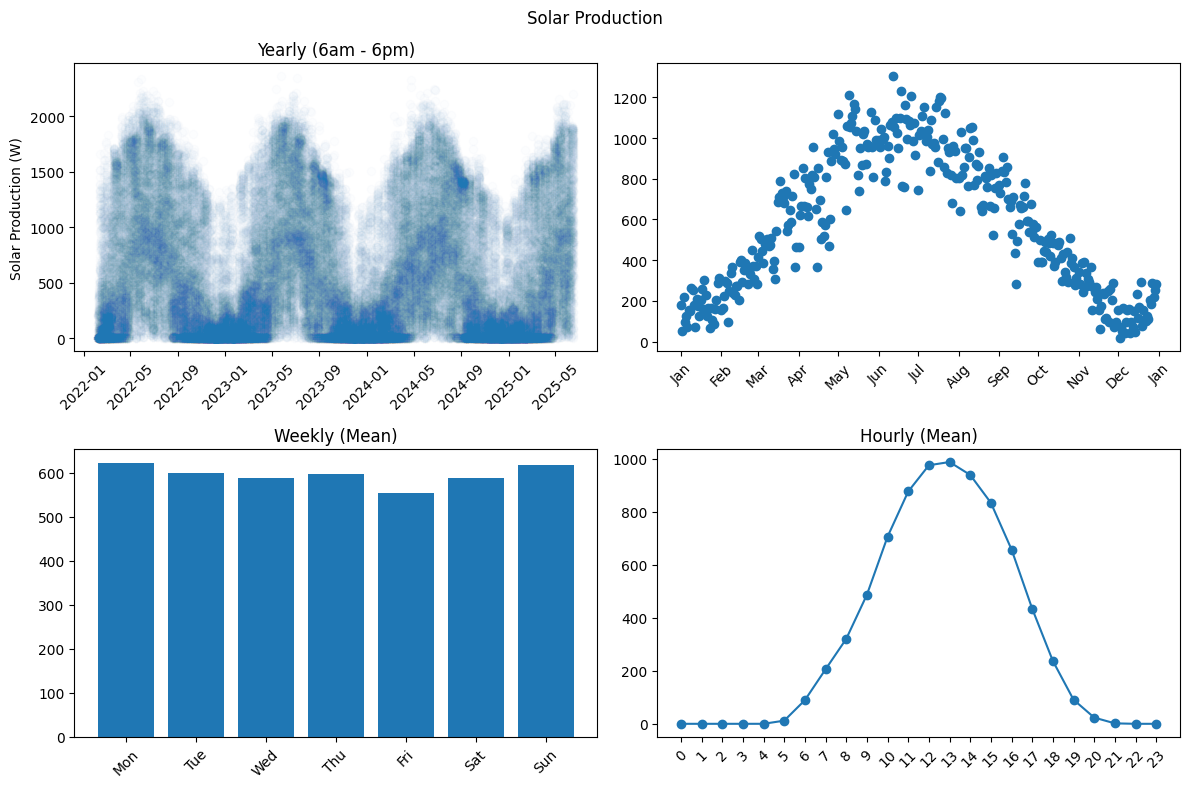

In [319]:
fig, ax = plt.subplots(2, 2, figsize = (12, 8))

df_days = df[(df.index.hour >= 6) & (df.index.hour <= 18)]
ax[0][0].scatter(df_days.index, df_days["Solarproduktion"], alpha=0.01)
ax[0][0].tick_params(axis='x', labelrotation=45)
ax[0][0].set_ylabel("Solar Production (W)")
ax[0][0].set_title("Yearly (6am - 6pm)")

df_days_daily = df_days.resample('D').mean()
df_days_yl = df_days_daily[~((df_days_daily.index.month == 2) & (df_days_daily.index.day == 29))]
df_days_yl = df_days_yl.groupby([df_days_yl.index.month, df_days_yl.index.day]).mean()
df_days_yl.index = pd.to_datetime([f"1970-{m:02d}-{d:02d}" for m, d in df_days_yl.index])
df_days_yl.sort_index(inplace=True)
ax[0][1].scatter(df_days_yl.index, df_days_yl["Solarproduktion"])
ax[0][1].xaxis.set_major_locator(mdates.MonthLocator())
ax[0][1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax[0][1].tick_params(axis='x', labelrotation=45)

df_days_wl = df_days.groupby([df_days.index.weekday]).mean()
ax[1][0].bar(df_days_wl.index, df_days_wl["Solarproduktion"])
ax[1][0].set_title("Weekly (Mean)")
ax[1][0].set_xticks(range(7))
ax[1][0].set_xticklabels(calendar.day_abbr, rotation=45)

df_days_h = df.resample('h').mean()
df_days_h = df_days_h.groupby([df_days_h.index.hour]).mean()
df_days_h.index = pd.Index(df_days_h.index, name="hour")
df_days_h = df_days_h.sort_index()
ax[1][1].plot(df_days_h.index, df_days_h["Solarproduktion"], marker='o')
ax[1][1].set_title("Hourly (Mean)")
ax[1][1].set_xticks(range(24))
ax[1][1].set_xticklabels(range(24), rotation=45)

fig.suptitle("Solar Production")
plt.tight_layout()
plt.show()

In [349]:
df_h = df.resample('h').mean()

df_monthly_h = (
    df_h
    .groupby([df_h.index.month, df_h.index.hour])[["Solarproduktion Tracker 1", "Solarproduktion Tracker 2", "Solarproduktion"]]
    .mean()
    .unstack(level=0)
)

fig, ax = plt.subplots(figsize=(8, 5))
line, = ax.plot([], [], marker='o', label=r'Solar Production ($\sum$)')
line1, = ax.plot([], [], marker='o', color='orange', label='Solar Production (North-East)')
line2, = ax.plot([], [], marker='o', color='green', label='Solar Production (South-West)')
ax.set_xlim(0, 23)
ax.set_ylim(0, df_monthly_h.max().max() * 1.1)
ax.set_xticks(range(24))
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Solar Production (W)")
ax.set_title("Mean Hourly Solar Production - January")
ax.legend(loc='upper left')

def update(month):
    line.set_data(df_monthly_h.index, df_monthly_h["Solarproduktion"][month])
    line1.set_data(df_monthly_h.index, df_monthly_h["Solarproduktion Tracker 1"][month])
    line2.set_data(df_monthly_h.index, df_monthly_h["Solarproduktion Tracker 2"][month])
    ax.set_title(f"Mean Hourly Solar Production - {pd.Timestamp(2024, month, 1).strftime('%B')}")
    return line,

plt.tight_layout()
plt.close()
ani = FuncAnimation(
    fig, update, frames=range(1, 13), interval=200, blit=True, repeat=True
)

writer = PillowWriter(fps=2)
ani.save("solar_animation.gif", writer=writer)

HTML(ani.to_jshtml())

# Correlation Analysis

In [238]:
df_solar = df.copy().resample('h').mean()

df_weather = pd.read_csv('weather.csv')
df_weather['time'] = pd.to_datetime(df_weather['time'])
df_weather.set_index('time', inplace=True)
df_weather = df_weather.resample('h').mean()

df_join = pd.merge(df_solar, df_weather, left_index=True, right_index=True)
df_join.head()

,Ladezustand,Batterie (Laden),Batterie (Entladen),Netzeinspeisung,Netzbezug,Solarproduktion Tracker 1,Solarproduktion Tracker 2,Solarproduktion Tracker 3,Solarproduktion,Hausverbrauch,...,cloud_cover (%),wind_speed_10m (km/h),precipitation (mm),weather_code (wmo code),relative_humidity_2m (%),pressure_msl (hPa),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),wind_gusts_10m (km/h)
2022-02-07 14:00:00,23.0,0.0,0.0,3.00,20.00,88.00,116.75,0.0,204.75,218.25,...,96.0,26.2,0.1,51.0,73.0,1014.8,13.0,20.0,0.0,59.0
2022-02-07 15:00:00,23.0,0.0,0.0,2.75,4.75,69.75,135.50,0.0,205.25,203.50,...,74.0,31.9,0.3,71.0,62.0,1015.6,36.0,61.0,0.0,60.8
2022-02-07 16:00:00,23.0,0.0,0.0,4.00,122.00,40.25,158.25,0.0,198.50,312.00,...,40.0,23.2,0.6,73.0,75.0,1016.9,20.0,26.0,0.0,58.0
2022-02-07 17:00:00,23.0,0.0,0.0,0.00,201.75,19.75,37.50,0.0,57.25,253.25,...,100.0,24.8,0.0,3.0,59.0,1017.3,11.0,100.0,0.0,49.0
2022-02-07 18:00:00,23.0,0.0,0.0,0.00,307.75,0.00,0.75,0.0,0.75,311.00,...,71.0,27.7,0.9,73.0,62.0,1018.4,40.0,63.0,0.0,51.5


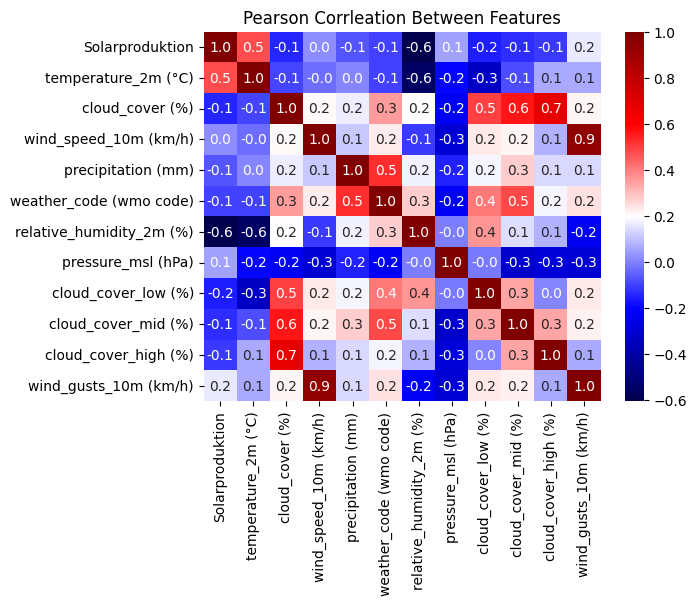

In [304]:
features = [
    "temperature_2m (°C)",
    "cloud_cover (%)",
    "wind_speed_10m (km/h)",
    "precipitation (mm)",
    "weather_code (wmo code)",
    "relative_humidity_2m (%)",
    "pressure_msl (hPa)",
    "cloud_cover_low (%)",
    "cloud_cover_mid (%)",
    "cloud_cover_high (%)",
    "wind_gusts_10m (km/h)"
]

corr_df = df_join[[
    "Solarproduktion",
    *features
]].corr()

sns.heatmap(corr_df, annot=True, fmt=".1f", cmap='seismic')
plt.title("Pearson Corrleation Between Features")
plt.show()

## Lagged Correlation

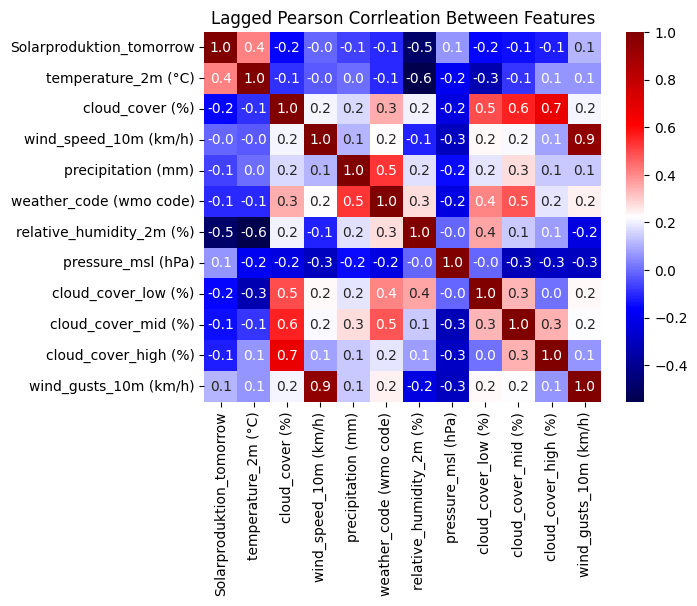

In [311]:
df_join['Solarproduktion_tomorrow'] = df_join['Solarproduktion'].shift(-1)
corr_df = df_join[[
    "Solarproduktion_tomorrow",
    *features
]].corr()

sns.heatmap(corr_df, annot=True, fmt=".1f", cmap='seismic')
plt.title("Lagged Pearson Corrleation Between Features")
plt.show()

# Interesting Dates

## Partial Solar Eclipse October 25, 2022

Timestamps taken from https://time.unitarium.com/events/eclipse/102022/city.html?city=Berlin-Germany&cix=549

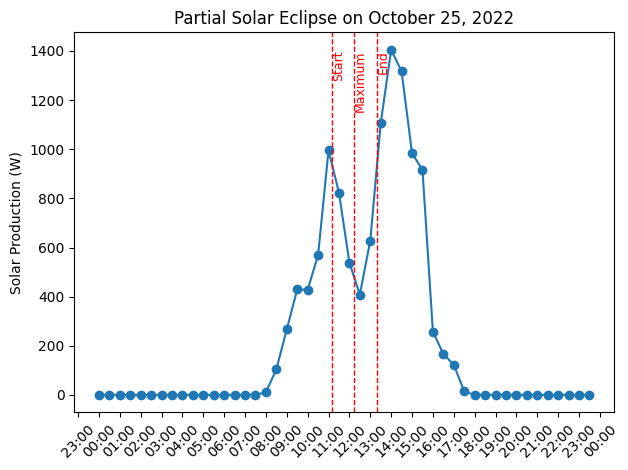

In [405]:
eclipse_df = df.resample('30min').mean()
eclipse_df = eclipse_df[
    (eclipse_df.index >= pd.Timestamp(day=25, month=10, year=2022)) &
    (eclipse_df.index < pd.Timestamp(day=26, month=10, year=2022))]
plt.plot(eclipse_df.index, eclipse_df["Solarproduktion"], marker='o', color='C0')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

vline_times = [
    pd.Timestamp('2022-10-25 11:09:45'),
    pd.Timestamp('2022-10-25 12:13:50'),
    pd.Timestamp('2022-10-25 13:19:15')
]
vline_labels = ['Start', 'Maximum', 'End']

for t, label in zip(vline_times, vline_labels):
    ax.axvline(x=t, color='red', linestyle='--', linewidth=1)
    ax.text(t, ax.get_ylim()[1]*0.95, label, rotation=90, 
            verticalalignment='top', horizontalalignment='left', fontsize=9, color='red')

plt.xticks(rotation=45)
plt.title("Partial Solar Eclipse on October 25, 2022")
plt.ylabel("Solar Production (W)")
plt.tight_layout()
plt.show()